# Importación de librerias

In [1]:
import os
import pandas as pd
from helpers_ps.Grafico.graf import Graph_mtplt
from helpers_ps.Config.var_globs import PALETA_COLORES

In [2]:
# Definición de Var globales de accesso a archivos
CODIGO_USUARIO = os.getlogin()
DIRECTORIO_LOCAL = os.getcwd().replace("\\", "/")
BASE_SELECTION = {
    "credicorp": "Credicorp/David Alonso Cuadros Negrete - PS",
    "onedrive": "OneDrive - Credicorp/Archivos de David Alonso Cuadros Negrete - PS",
}

# Directorios de información
IMPORT_PATH_CHARTBOOK = f"D:/Datos de Usuarios/{CODIGO_USUARIO}/Credicorp/Mandatos Perú - Documents/6 - Celula de RV/2 - Monitor.xlsx"

def import_chartbook(open_excel: bool = False, file: str = IMPORT_PATH_CHARTBOOK) -> pd.DataFrame:
    
    """
    Importar datos desde el Excel de Chartbook de Renta Variable.
    Si el archivo está abierto en Excel, se importa directamente desde allí utilizando xlwings.
    Si no está abierto, se importa desde la ruta especificada utilizando pandas.

    Parámetros:
    ----------------
    open_excel (bool): Indica si el archivo de Excel está abierto. Por defecto es False.
    
    file (str): Ruta al archivo de Excel. Por defecto es IMPORT_PATH_CHARTBOOK

    Retorna:
    ----------------
    data (pd.DataFrame): DataFrame con los datos de precios desde la hoja "Data".
    
    activos (pd.DataFrame): DataFrame con la información de los activos desde la hoja "Base".

    """
    
    data = pd.read_excel(file, skiprows=12, usecols= lambda x: x not in ["A", "B"], sheet_name="Data", engine="openpyxl")
    data = data.set_index("Fecha")    
    activos = pd.read_excel(file, skiprows=2, usecols= lambda x: x not in ["A"], sheet_name="Base", engine="openpyxl")    
    activos = activos.drop(columns=["Unnamed: 0"])
    activos = activos.set_index("Ticker")

    return data, activos

data, activos = import_chartbook()

# Ejemplos de gráficos

## Grafico de lineas

In [3]:
# Construir data frame en uso
_tickers = ["PX_LAST-SPX INDEX", "PX_LAST-RUO INDEX"]
_data = data[_tickers]

In [4]:
# Inicializar el objeto con uno de los inputs siendo el data frame
graph = Graph_mtplt(dataframe = _data)
graph.graph_line(
    figsize=(6,5),                                                                                                  # Configuración del tamaño de la figura sobre el cual se construye el grafico
    tickers = "all",                                                                                                # Tickers (nombre de columnas) que se van a mostrar: "all" = Todos | "ticker" | ["ticker1", "ticker2",..., "tickerN"]
    labels = ["S&P 500", "Russell 2000"],                                                                           # Labels de cada serie (Overwrite el column name): None = default usar tickers | ["label_of_ticker1", "label_of_ticker2",...,"label_of_tickerN"]
    colors = ["black"],                                                                                             # Colores de cada serie (Overwrite el color): None = default usar paleta CC | ["color_of_ticker1", "color_of_ticker2",...,"color_of_tickerN"]
    titles=dict(                                                                                                    # Hereda todas las funcionalidades de la función self.set_titles()
        title="Precio del SPX",
        subtitle="Evolución del precio del SPX desde 1990"
    ),                                                                                                              
    source = dict(                                                                                                  # Hereda todas las funcionalidades de la función self.add_source()
        text = [f"Fuente: Bloomberg, con información al cierre del","Nota 1: Maje estuvo aqui"]
    ),
    x_axis=dict(                                                                                                    # Hereda la funcionalidades de _prep_x_axis
        tick_step=25, 
        bbg_format=True,
        fmt="%b-%Y",
        lim = ("2015-01-01", None),
        fontsize=6
    ),
    tag_dot={                                                                                                       # Agrega tag | dot | dot_tag a una serie de lineas
        "1": dict(                                                                                                  # key random solo para diferencia agrupación (permite agregar grupos de etiquetas configurables para una misma serie)
            ticker="PX_LAST-SPX INDEX",                                                                             # ticker (nombre de columna) de sobre la serie que se quiere trabajar
            x_values = ["last", pd.Timestamp("2025-12-31")],                                                        # puntos del eje x donde se quiere colocar x_values = "last" | x_values = "all" | x_values = ["last", "2025-04-05", ...]
            template = "{y_value:,.0f}",                                                                            # template para el label que se quiere poner en la etiqueta
            show="dot_tag",                                                                                         # que se quiere mostrar show = dot (muestra solo punto) | show = tag (muestra solo la etiqueta) | dot_tag (muestra ambos etiqueta y punto)
            dot = dict(                                                                                             # Hereda todas las funcionalidades de self.punto_valor()
                color="green",
                size=22,
            ),
            tag = dict(                                                                                             # Hereda todas las funcionalidad de self.etiqueta_valor()
                bg_color="none"
            )
        ),
        "2": dict(
            ticker="PX_LAST-RUO INDEX",
            x_values = [pd.Timestamp("2020-12-31")],
            template = "{y_value:,.0f}",
            show="dot_tag",
            dot = dict(
                size=22,
                zorder=50,
                color="red"
            ),
            tag = dict(
                bg_color="none",
                font_color="red"
            )
        ),
    },
    legend = dict(                                                                                                  # Hereda todas las funcionalidad de self.add_legend()
        show = True,
    ),
    hlines=dict(                                                                                                    # Hereda todas las funcionalidades de self.horizontal_lines()
        y_values=[4000],
        linestyle="--",
        color="brown"
    )
)
# Agregar recesiones al grafico de lineas
graph.add_recesiones(
    country="Peru"
)
# Guardar grafico en dict
dict_ejemplos = {}

graph.save(dict_ejemplos, name="Precio_SPX")

## Gráfico de barras

In [ ]:
# Construir data frame en uso
_data_bar = _data.copy()
_data_bar = _data_bar.resample("ME").last()
_data_bar = _data_bar.tail(12)

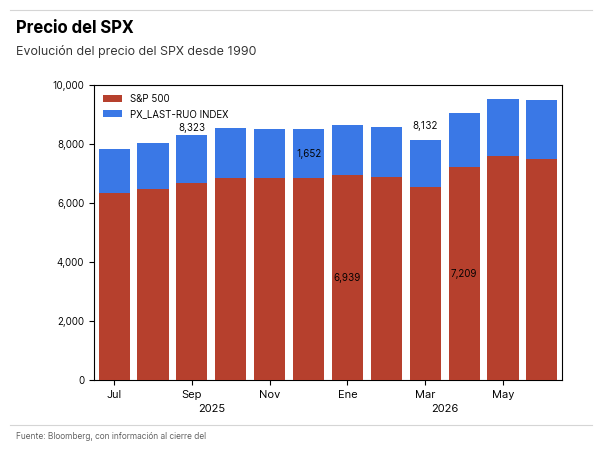

In [26]:
graph = Graph_mtplt(dataframe = _data_bar)
graph.graph_bar(
    tickers = "all",
    labels = ["S&P 500"],
    colors = PALETA_COLORES[3],
    titles=dict(
        title="Precio del SPX",
        subtitle="Evolución del precio del SPX desde 1990"
    ),
    source = dict(
        text = [f"Fuente: Bloomberg, con información al cierre del"]
    ),
    bar_mode = "time",
    stacked = True,
    grouped=False,
    bar_labels={
        "1": dict(
            ticker="PX_LAST-SPX INDEX",
            x_values = ["2026-04-30", "2026-01-31"],
            template = "{y_value:,.0f}",
            bg_color="None",
            ubic_etq=(0,0)
        ),
        "2": dict(
            ticker="PX_LAST-RUO INDEX",
            x_values = ["2025-12-31", "2026-11-30"],
            template = "{y_value:,.0f}",
            bg_color="None",
            ubic_etq=(0,0)
        ),
    },
    bar_tags={
        "1": dict(
            ticker="PX_LAST-SPX INDEX",
            x_values = ["2025-09-30", "2026-03-31"],
            template = "{total_value:,.0f}",
            bg_color="None",
            ubic_etq=(0,0),
            show="stack_total"
        ),
    },
    x_axis=dict(
        tick_step=2,
        fontsize=8,
        bbg_format=True,
        fmt="%Y-%m",
        ),
    legend=dict(
        show=True,
        ncol=1
    )
)